In [1]:
import numpy as np
import pandas as pd
import yaml
from pathlib import Path
import orca

from mazsim import data, variables

In [2]:
project_dir = Path.cwd().parent
orca.add_injectable("project_dir", project_dir)
orca.run(['load_data', 'build_networks','register_variables'])

Running step 'load_data'
Time to execute step 'load_data': 10.63 s
Running step 'build_networks'
Number of nodes is 160520.
Number of edges is 385130.
Precomputing network for distance 3000.
Network precompute starting.
Network precompute done.
Time to execute step 'build_networks': 3.69 s
Running step 'register_variables'
Time to execute step 'register_variables': 0.19 s
Total time to execute iteration 1 with iteration value None: 14.51 s


In [3]:
from urbansim.models import util
from urbansim_templates import modelmanager as mm
from urbansim_templates.models import LargeMultinomialLogitStep

from urbansim.models.util import (columns_in_filters, columns_in_formula)
from choicemodels.tools import MergedChoiceTable

mm.initialize(Path.joinpath(project_dir, "configs"))

No files from ModelManager 0.1.dev8 or later found in path 'c:\Users\jkolberg\PythonProjects\PSRC\mazsim\projects\baseline_summer2026\configs'


In [4]:
import matplotlib.pyplot as plt
%matplotlib notebook
%matplotlib inline

import seaborn as sb

from bokeh.io import output_notebook#, show
# from bokeh.plotting import Figure
# from datashader.bokeh_ext import create_ramp_legend, create_categorical_legend

output_notebook()

import datashader.transfer_functions as tf

import datashader as ds
from datashader.colors import viridis

def visualize_variable(variable_name):
    p = orca.get_table('blocks').to_frame(['x', 'y', variable_name])
    
    cvs = ds.Canvas(plot_width=1000, plot_height=700)
    agg = cvs.points(p, 'x', 'y', ds.mean(variable_name))
    img = tf.set_background(tf.shade(agg, cmap=viridis),"white")
    return img

def summed_probas(sum_variable, probas):
    p = orca.get_table('blocks').to_frame([sum_variable])
    p['proba'] = probas

    summed_puma = p.groupby(sum_variable).proba.sum()

    (summed_puma / summed_puma.sum()).plot(kind='bar')

def plot_probas(proba):
    p = orca.get_table('blocks').to_frame(['x', 'y'])
    p['proba'] = proba

    cvs = ds.Canvas(plot_width=1000, plot_height=700)
    agg = cvs.points(p, 'x', 'y', ds.mean('proba'))
    img= tf.set_background(tf.shade(agg, cmap=viridis),"white")
    return img

def corr_plot(selected_variables):
    cols = []
    for col in selected_variables:    
        if col.startswith('np'):
            cols.append(col.split('(')[-1][:-1])
        else:
            cols.append(col)

    X = orca.get_table('blocks').to_frame(cols)

    plt.subplots(figsize=(12, 12))
    sb.heatmap(X.corr(), annot=True, cmap="RdYlGn")
    plt.show()
    
def skew_plot(selected_variables):
    cols = []
    for col in selected_variables:    
        if col.startswith('np'):
            cols.append(col.split('(')[-1][:-1])
        else:
            cols.append(col)
            
    X = orca.get_table('blocks').to_frame(cols)
    X.skew().plot(kind='bar')

def create_probs_table(m, rep_chooser_filter = None, sample_alts= None, sample_choosers= None,idx='building_id'):
    filter_cols = columns_in_filters(to_str(m.chooser_filters) + " " + to_str(m.alt_filters) + to_str(rep_chooser_filter))
    colnames = columns_in_formula(m.model_expression) + columns_in_filters(filter_cols)
    alts = orca.get_table(m.alternatives).to_frame(colnames)
    alts = alts.query(to_str(m.alt_filters)) if m.alt_filters else alts
    obs = orca.get_table(m.choosers).to_frame(colnames)
    obs = obs.query(to_str(m.chooser_filters)) if m.chooser_filters else obs
    if idx in obs.columns:
        obs = obs.drop(columns=[idx])
    # Filter representative chooser based on rep_chooser_filter input
    if rep_chooser_filter:
        # check if rep_filter has columns from the interaction terms
        if (all(x in obs.columns for x in columns_in_filters(to_str(rep_chooser_filter)))):
            obs = obs.query(to_str(rep_chooser_filter))
        else:
            chooser_vars = [x for x in columns_in_formula(m.model_expression) if x in orca.get_table(m.choosers).columns]
            raise ValueError("Representative choosers' filters must be on these columns:\n *{}".format('\n *'.join(chooser_vars)))
    if sample_choosers:
        if sample_choosers <= len(obs):
            obs = obs.sample(n= sample_choosers)
        else:
            obs
    if len(obs) == 0:
        raise ValueError('No choosers left after filtering.')
    if len(alts) == 0:
        raise ValueError('No alternatives left after filtering.')
    
    if not sample_alts:
        sample_alts = len(alts)
    mtc = MergedChoiceTable(obs, alts, sample_size= sample_alts)
    probas = m.model.probabilities(mtc)
    probas = probas.reset_index(level=1).groupby(idx).sum()
    return probas

def to_str(w):
    if isinstance(w, str):
        return w
    if isinstance(w, list):
        return ' & '.join(w) if len(w) > 1 else w[0]
    if not w:
        return " "

Loading BokehJS ...

In [5]:
# Set explanatory variables
expl_vars = [
    'st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time',
    'st_ln_block_groups_mean_rent',
    'st_is_transit_stop_sum_1600_flat',
    'st_block_groups_median_income', 
    'st_block_groups_prop_year_built_2022', 
    'st_block_groups_prop_children_0',
    'st_ln_block_groups_density_housing_units'
]

In [7]:
m = LargeMultinomialLogitStep()
m.choosers = ['households']
m.chooser_sample_size = 5000
m.chooser_filters = '(recent_mover == 1) & (income_quartile == 4)'
m.alternatives = ['blocks']
m.choice_column = 'block_id'
m.constrained_choices = True
m.alt_sample_size = 100 
m.out_chooser_filters = '(block_id == "-1") & (income_quartile == 4)'
m.alt_capacity = 'vacant_housing_units'
m.out_alt_filters = 'vacant_housing_units > 0'

m.model_expression = util.str_model_expression(expl_vars, add_constant=False)
m.fit()
m.name = 'hlcm1'

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          5,000
Model:         Multinomial Logit   Df Residuals:              4,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-01   Pseudo R-squ.:             0.066
Time:                      16:04   Pseudo R-bar-squ.:         0.065
AIC:                  43,048.543   Log-Likelihood:      -21,517.272
BIC:                  43,094.164   LL-Null:             -23,025.851
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time    0.0524     0.032     1.651     0.099             
st_ln_block_groups_mean_rent                                               0.0934

In [13]:
children_vars = [col for col in orca.get_table('block_groups').columns if 'year' in col]
children_vars

['mean_year_built',
 'median_year_built',
 'std_year_built',
 'prop_year_built_2000',
 'prop_year_built_1990',
 'prop_year_built_1980',
 'prop_year_built_1970',
 'prop_year_built_2010',
 'prop_year_built_1960',
 'prop_year_built_1939',
 'prop_year_built_1950',
 'prop_year_built_1940',
 'prop_year_built_2020',
 'prop_year_built_2021',
 'prop_year_built_2022']

Disaggregating density_housing_units to blocks from block_groups
Calculating density of housing_units for block_groups
Calculating number of housing_units for block_groups
Disaggregating block_group_id to housing_units from blocks
Calculating sum_acres of blocks for block_groups


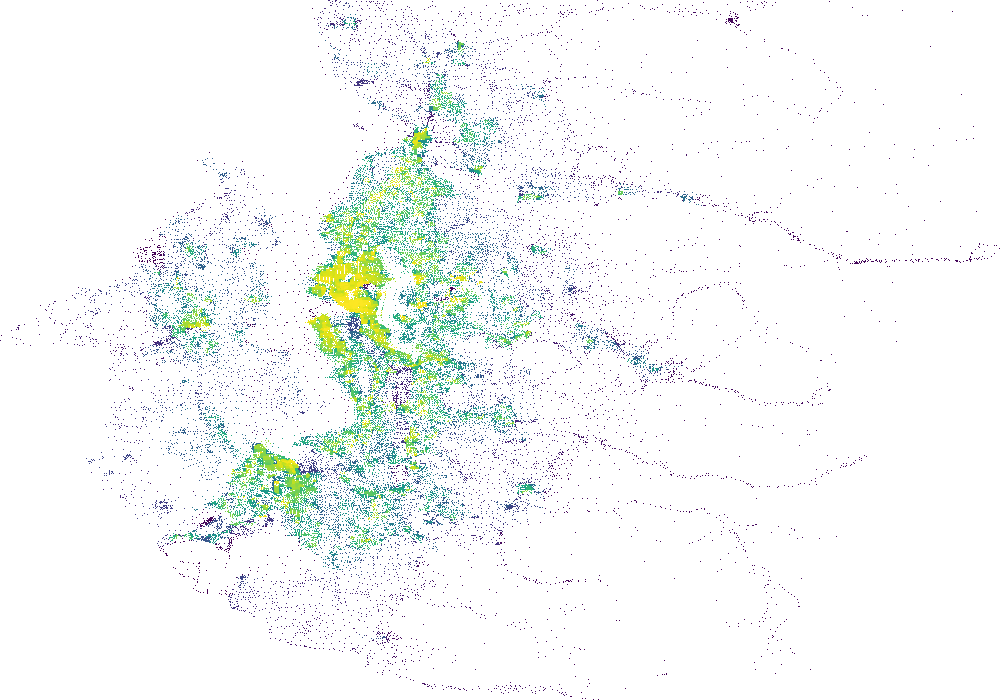

In [6]:
visualize_variable('block_groups_density_housing_units')